# Basic Data Operations

A simple example showing how to download a dataset from neurovault and perform
basic data operations.  The bulk of the nltools toolbox is built around the
Brain_Data() class.  This class represents imaging data as a vectorized
features by observations matrix.  Each image is an observation and each voxel
is a feature.  The concept behind the class is to have a similar feel to a pandas
dataframe, which means that it should feel intuitive to manipulate the data.

## Download pain dataset from neurovault

Here we fetch the pain dataset used in [Chang et al., 2015](http://journals.plos.org/plosbiology/article?id=10.1371/journal.pbio.1002180)
from [neurovault](http://neurovault.org/collections/504/). In this dataset
there are 28 subjects with 3 separate beta images reflecting varying intensities
of thermal pain (i.e., high, medium, low).  The data will be downloaded to ~/nilearn_data,
and automatically loaded as a Brain_Data() instance.  The image metadata will be stored in data.X.

In [ ]:
from nltools.datasets import fetch_pain

data = fetch_pain()

## Load files

Nifti images can be easily loaded simply by passing a string to a nifti file.
Many images can be loaded together by passing a list of nifti files.
For example, on linux or OSX systmes, the downloads from fetch_pain() will be
stored in ~/nilearn_data.  We can load the full dataset at once:

In [ ]:
from nltools.data import Brain_Data
from pathlib import Path

home = Path().home()

data = Brain_Data(list((home / 'nilearn_data' / 'neurovault' / 'collection_504').glob('*.nii.gz')))

## Basic Brain_Data() Operations

Here are a few quick basic data operations.
Find number of images in Brain_Data() instance

In [55]:
len(data)

84

Find the dimensions of the data.  images x voxels

In [56]:
data.shape()

(84, 238955)

We can use any type of indexing to slice the data such as integers, lists
of integers, or boolean.

In [59]:
data[[1,6,2]]

nltools.data.brain_data.Brain_Data(data=(3, 238955), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)

Calculate the mean for every voxel over images

In [60]:
data.mean()

nltools.data.brain_data.Brain_Data(data=(238955,), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)

Calculate the standard deviation for every voxel over images

In [61]:
data.std()

nltools.data.brain_data.Brain_Data(data=(238955,), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)

Methods can be chained.  Here we get the shape of the mean.

In [62]:
data.mean().shape()

(238955,)

Brain_Data instances can be added and subtracted

In [63]:
new = data[1]+data[2]

Brain_Data instances can be manipulated with basic arithmetic operations
Here we add 10 to every voxel and scale by 2

In [64]:
data2 = (data+10)*2

Brain_Data instances can be copied

In [65]:
new = data.copy()

Brain_Data instances can be easily converted to nibabel instances, which
store the data in a 3D/4D matrix.  This is useful for interfacing with other
python toolboxes such as [nilearn](http://nilearn.github.io/)

In [66]:
data.to_nifti()

Brain_Data instances can be concatenated using the append method

In [67]:
new = new.append(data[4])

Any Brain_Data object can be written out to a nifti file

In [40]:
data.write('Tmp_Data.nii.gz')

Images within a Brain_Data() instance are iterable.  Here we use a list
comprehension to calculate the overall mean across all voxels within an
image.

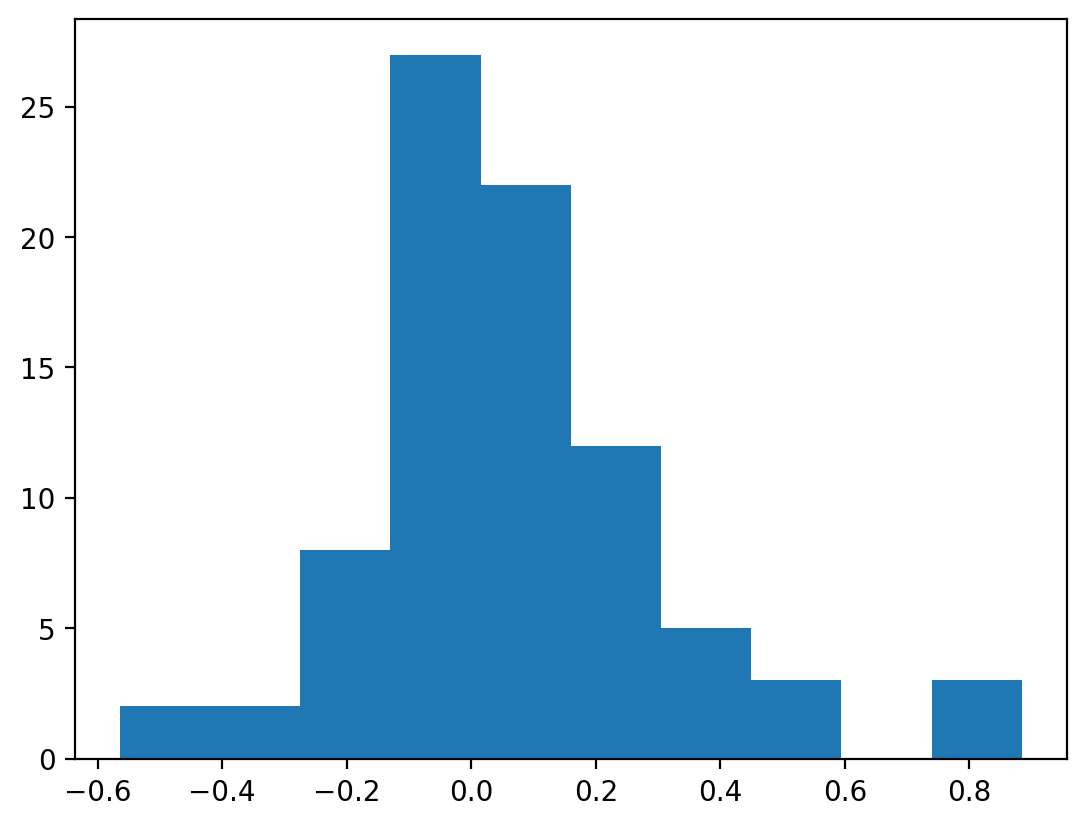

In [68]:
import matplotlib.pyplot as plt
plt.hist([x.mean() for x in data]);

## Basic Brain_Data() Plotting

There are multiple ways to plot data.  First, Brain_Data() instances can be
converted to a nibabel instance and plotted using any plot method such as
nilearn.

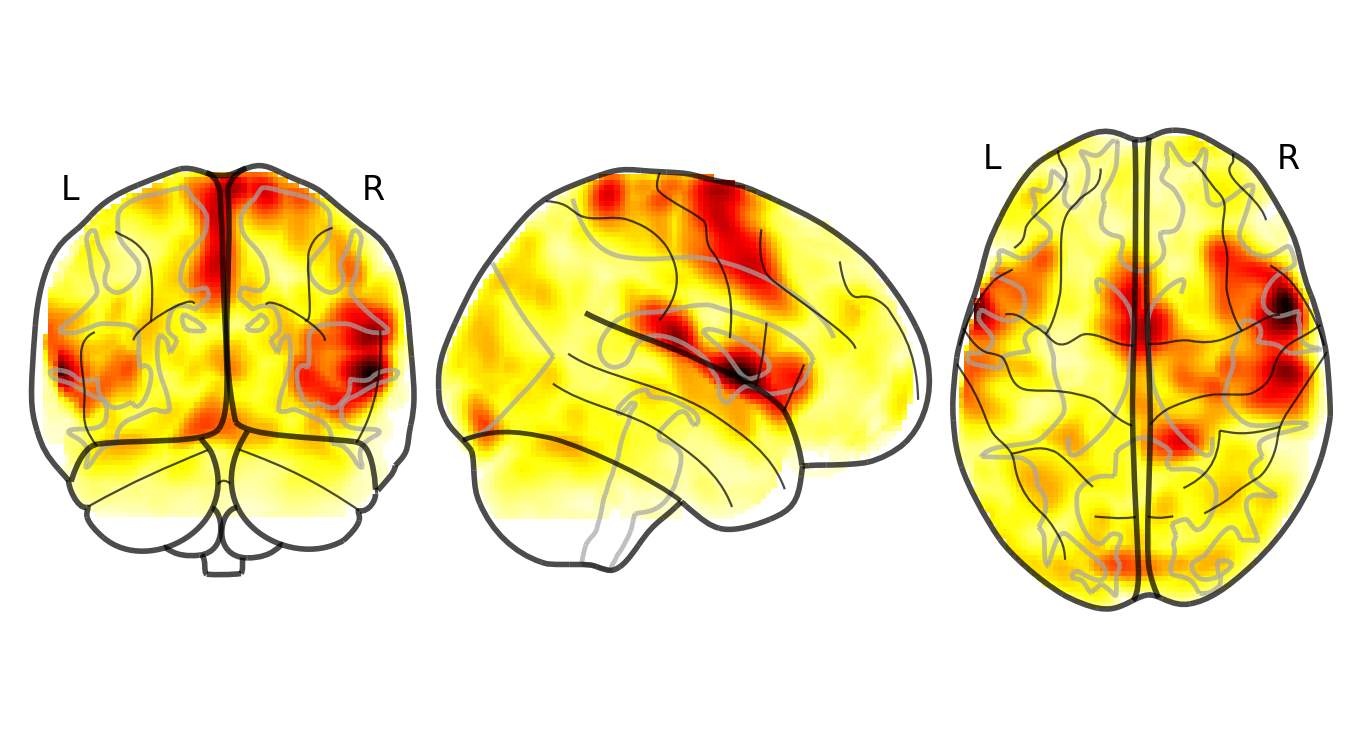

In [69]:
from nilearn.plotting import plot_glass_brain

plot_glass_brain(data.mean().to_nifti())

Or plotted with the `.plot()` method which can render multiple nilearn plots at once

Plotting unthresholded image


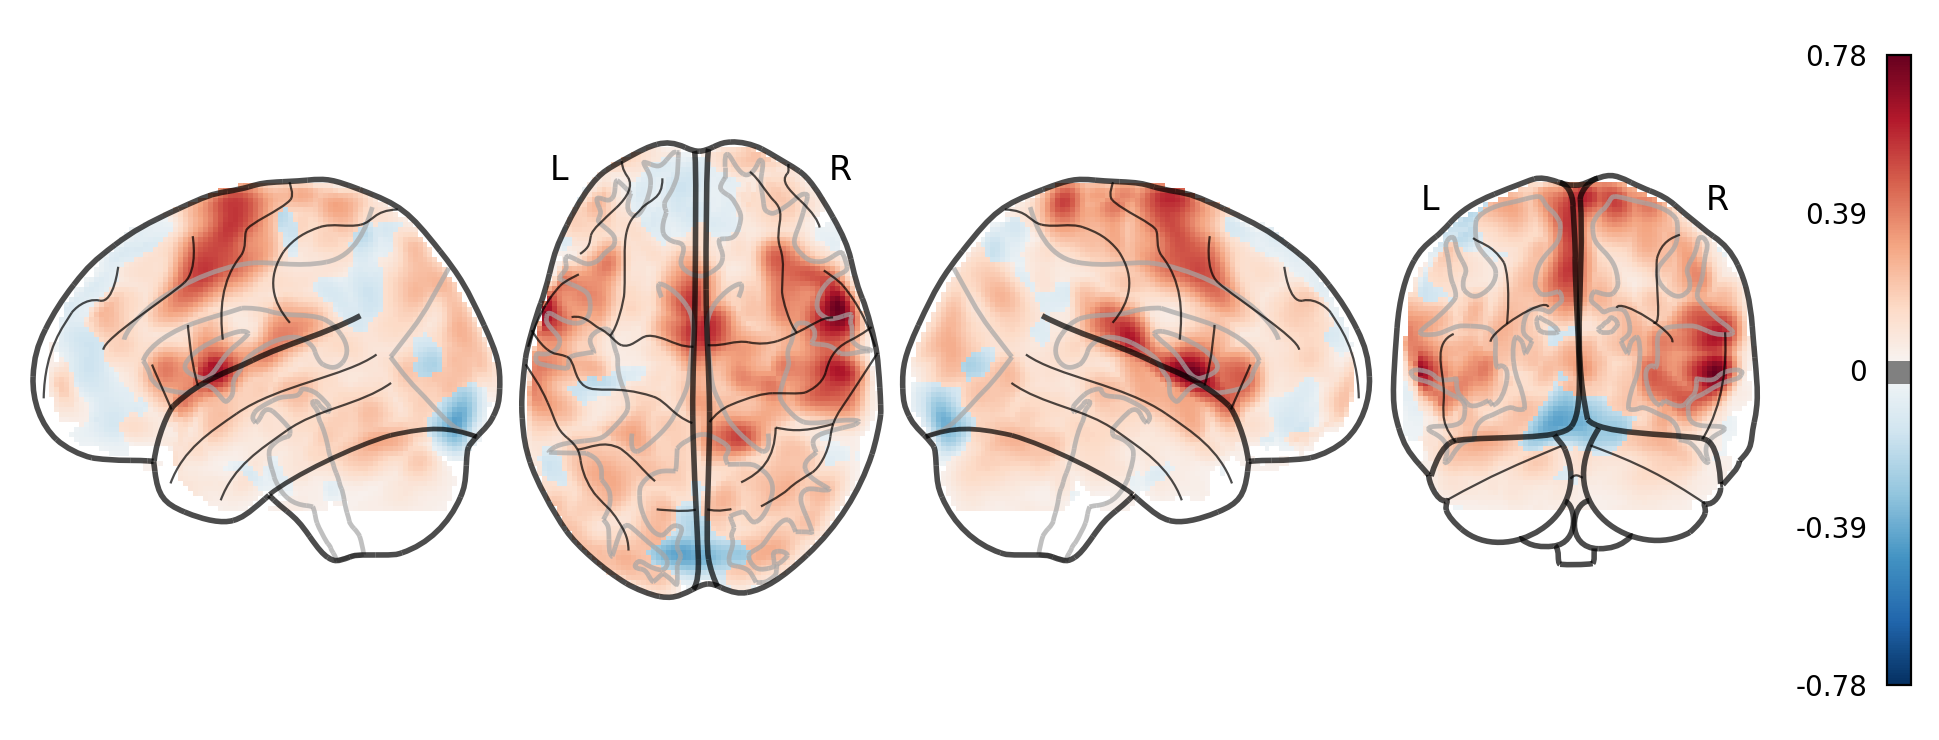

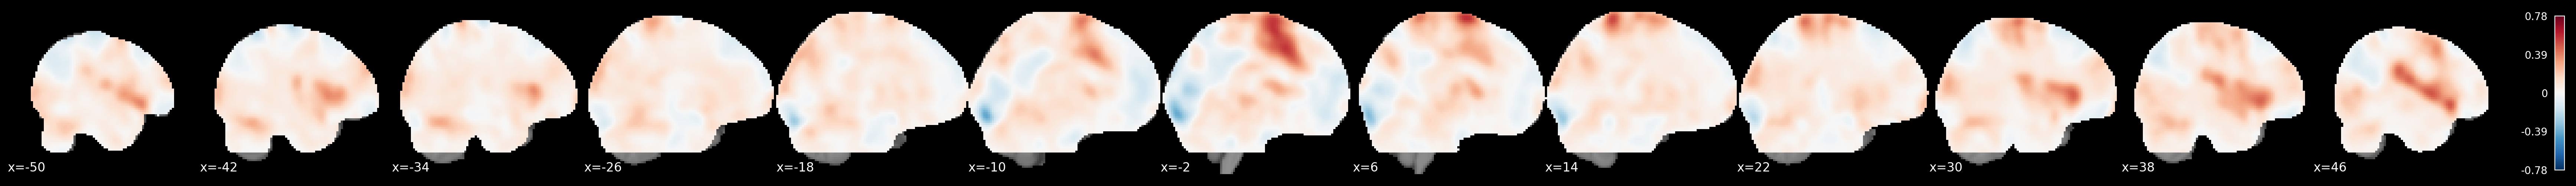

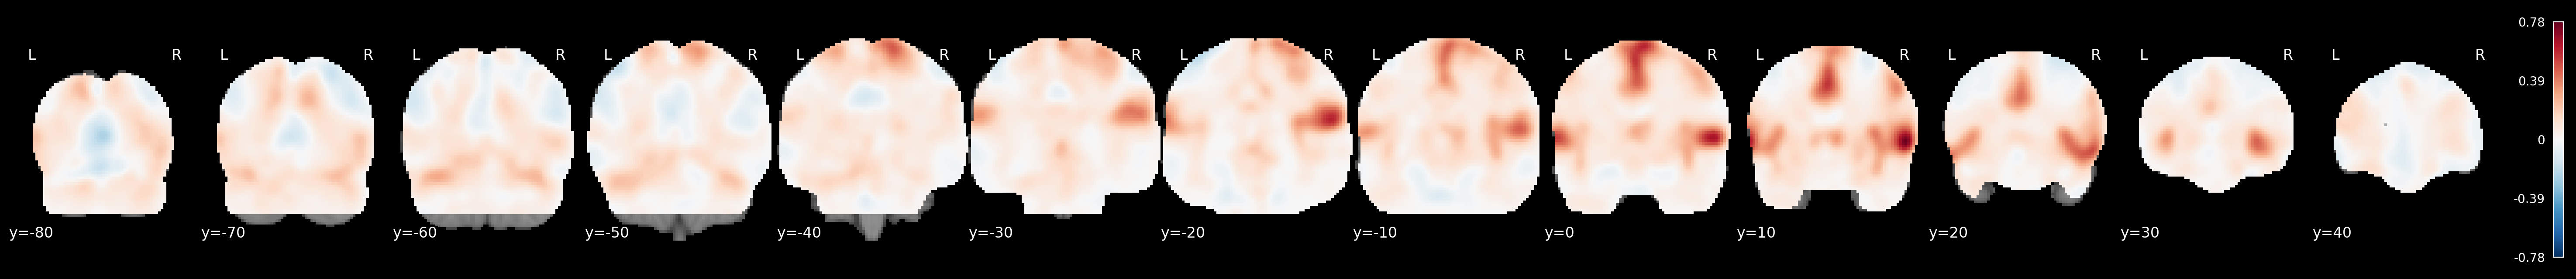

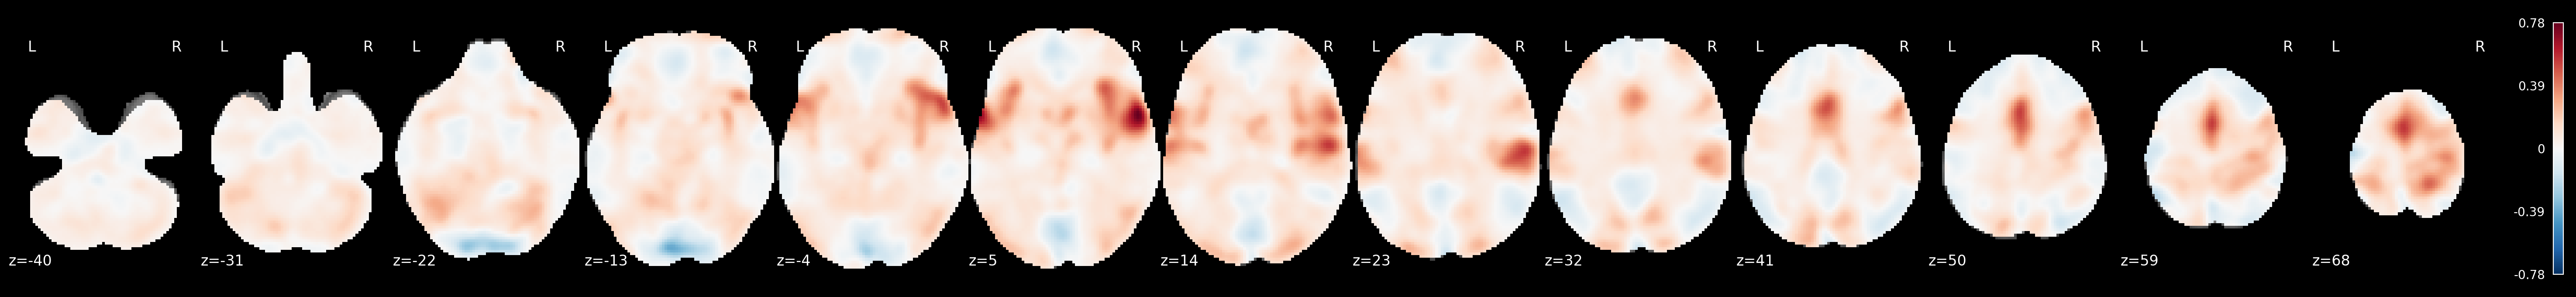

In [71]:
data.mean().plot(view='full')

There is also a fast montage plotting method.  Here we plot the average image
it will render a separate plot for each image.  There is a 'limit' flag
which allows you to specify the maximum number of images to display.

In [ ]:
# Currently plots with broken dimension
# data.plot(limit=3);